<a href="https://colab.research.google.com/github/cathdong66-lgtm/EMSC2010-Data-Science-Fair/blob/main/Copy_of_EMSC2010_Group_Project_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Group Project template

## 1. Project Overview
Group name:

Project week:

Project title:

Datasets used (name and source):

## 2. Roles and contributions

| Role | Primary | Deputy | Completed? | Notes |
| :--- | :--- | :--- | :--- | :--- |
| Github & integration | Name | Name | Yes/Partial/No| Add note|
| Data steward | Name | Name | Yes/Partial/No| Add note|
| Analysis / modelling | Name | Name | Yes/Partial/No| Add note|
| Visualisation / interpretation | Name | Name | Yes/Partial/No| Add note|
| Narrative | Name | Name | Yes/Partial/No| Add note|
| Quality Control / Reproducibility  | Name | Name | Yes/Partial/No/NA| Add note|


## 3. Deputy Interventions (if applicable)
Repeat text as required.

* Role affected:

* Reason (e.g. missed deadline, absence, etc.):

* Deputy action taken:

* Impact on workflow:

*N.B., this section should be factual, not judgemental.*

## 4. Pre-submission checklist
* Notebook runs from top to bottom.
* Datafiles are included in the GitHub repository.
* Commits include meaningful information.
* Each group member has included a brief reflection in the notebook.
* Repository has been shared with the teaching team once your project is completed.

# Start your group project here

In [25]:
#import packages

import pymc as pm #estimates posterior distributions
import numpy as np
import pandas as pd #used to read and clean data
from scipy import stats

In [26]:
# This cell defines variables for the Excel spreadsheet and sheet names.
# These variables will be used later to import data from the specified sheets.
spreadsheet_name = 'Sydney_Data.xlsx' # Name of the Excel file containing the ice melt data.
Badgerys_Creek = 'Badgerys Creek' # Name of the worksheet containing the data.
Parramatta = 'Parramatta' # Corrected: Removed the trailing space to match the actual sheet name.

In [27]:
Badgerys_Creek_df = pd.read_excel(
    spreadsheet_name, # Pass the variable holding the Excel file name to `read_excel`.
    sheet_name=Badgerys_Creek, # Specify the sheet named 'Sheet1' to read data for Greenland
    skiprows=0,      # Skip the first row, as it contains headers that are not part of the data.
)

Parramatta_df = pd.read_excel(
    spreadsheet_name, # Pass the variable holding the Excel file name to `read_excel`.
    sheet_name=Parramatta, # Specify the sheet named 'Sheet1' to read data for Greenland
    skiprows=0,      # Skip the first row, as it contains headers that are not part of the data.
)
Parramatta_df.head() # Display the first few rows of the created DataFrame to verify data loading and structure.

,Product code,Bureau of Meteorology station number,Year,Month,Day,Maximum temperature (Degree C),Days of accumulation of maximum temperature,Quality
0,IDCJAC0010,66124,1967,1,1,NaN,NaN,NaN
1,IDCJAC0010,66124,1967,1,2,NaN,NaN,NaN
2,IDCJAC0010,66124,1967,1,3,NaN,NaN,NaN
3,IDCJAC0010,66124,1967,1,4,NaN,NaN,NaN
4,IDCJAC0010,66124,1967,1,5,NaN,NaN,NaN


In [28]:
Badgerys_Creek_df.head()

,Product code,Bureau of Meteorology station number,Year,Month,Day,Maximum temperature (Degree C),Days of accumulation of maximum temperature,Quality
0,IDCJAC0010,67108,1995,1,1,NaN,NaN,NaN
1,IDCJAC0010,67108,1995,1,2,NaN,NaN,NaN
2,IDCJAC0010,67108,1995,1,3,NaN,NaN,NaN
3,IDCJAC0010,67108,1995,1,4,NaN,NaN,NaN
4,IDCJAC0010,67108,1995,1,5,NaN,NaN,NaN


In [37]:
# Extract relevant columns and clean data
# For urban (Parramatta)
urban_data = Parramatta_df[['Year', 'Month', 'Day', 'Maximum temperature (Degree C)']].dropna()
urban_temp = urban_data['Maximum temperature (Degree C)'].values
t_urban = urban_data['Year'].values

# For rural (Badgerys Creek)
rural_data = Badgerys_Creek_df[['Year', 'Month', 'Day', 'Maximum temperature (Degree C)']].dropna()
rural_temp = rural_data['Maximum temperature (Degree C)'].values
t_rural = rural_data['Year'].values

# Linear regressions
urban_fit = stats.linregress(t_urban, urban_temp)
rural_fit = stats.linregress(t_rural, rural_temp)

# Extract slopes and standard errors
beta_u = urban_fit.slope
se_u = urban_fit.stderr

beta_r = rural_fit.slope
se_r = rural_fit.stderr

# Simulate posterior distributions
n_samples = 100000

beta_u_samples = np.random.normal(beta_u, se_u, n_samples) #creates 100,000 random samples of warming rates
beta_r_samples = np.random.normal(beta_r, se_r, n_samples)

# Probability urban warming faster
prob = np.mean(beta_u_samples > beta_r_samples) #probability that out of the 100,000 random samples, the urban warms faster

print(f"Probability urban warming faster = {prob:.3f}")

Probability urban warming faster = 0.168


/tmp/ipykernel_5922/388079623.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  urban_monthly_mean = urban_data['Maximum temperature (Degree C)'].resample('M').mean()
/tmp/ipykernel_5922/388079623.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rural_monthly_mean = rural_data['Maximum temperature (Degree C)'].resample('M').mean()


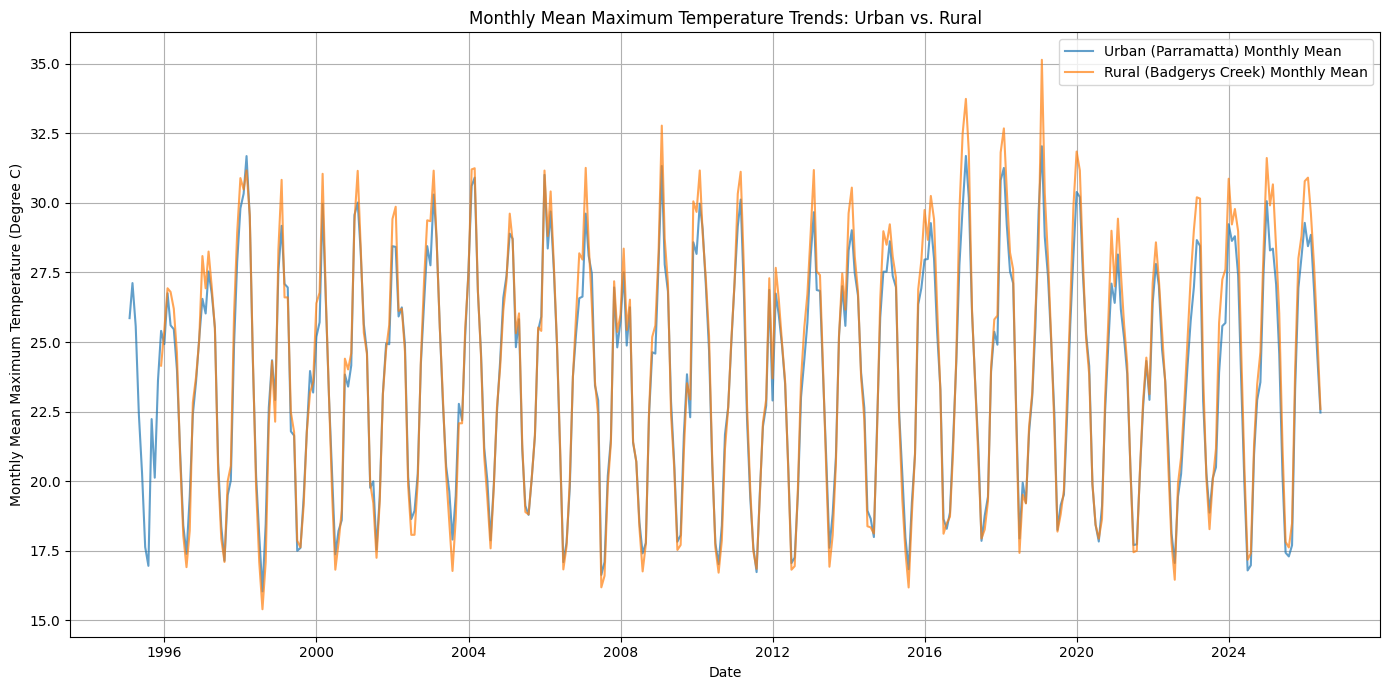

In [38]:
# Create a datetime index for urban data
urban_data['Date'] = pd.to_datetime(urban_data[['Year', 'Month', 'Day']])
urban_data = urban_data.set_index('Date')

# Create a datetime index for rural data
rural_data['Date'] = pd.to_datetime(rural_data[['Year', 'Month', 'Day']])
rural_data = rural_data.set_index('Date')

# Calculate monthly mean temperatures
urban_monthly_mean = urban_data['Maximum temperature (Degree C)'].resample('M').mean()
rural_monthly_mean = rural_data['Maximum temperature (Degree C)'].resample('M').mean()

# Determine the common start year (1995 based on t_rural's start)
common_start_date = '1995-01-01'

# Filter both datasets to the common time domain
urban_monthly_mean_aligned = urban_monthly_mean[urban_monthly_mean.index >= common_start_date]
rural_monthly_mean_aligned = rural_monthly_mean[rural_monthly_mean.index >= common_start_date]

# Plotting the monthly mean temperatures
plt.figure(figsize=(14, 7))
plt.plot(urban_monthly_mean_aligned.index, urban_monthly_mean_aligned.values, label='Urban (Parramatta) Monthly Mean', alpha=0.7)
plt.plot(rural_monthly_mean_aligned.index, rural_monthly_mean_aligned.values, label='Rural (Badgerys Creek) Monthly Mean', alpha=0.7)

plt.xlabel('Date')
plt.ylabel('Monthly Mean Maximum Temperature (Degree C)')
plt.title('Monthly Mean Maximum Temperature Trends: Urban vs. Rural')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()